<a href="https://colab.research.google.com/github/your-org/alexpose/blob/main/experiments/multiple-sclerosis/04_progressive_finetune_ms_pd_vicreg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 - Two ways to adapt the encoder: SSL continuation vs supervised adaptation

Notebook 03 trained the encoder with **no labels** on all the walking motion in the training set. Now we ask a sharper question: once we do have diagnosis labels, what is the honest way to use them, and does it actually help the three conditions separate?

We compare two clearly named regimes, both starting from the same label-free checkpoint:

1. **SSL continuation** - keep training with the *same* label-free objective for more updates. No labels touch the model.
2. **Balanced supervised adaptation** - freeze the encoder and fit a small, class-balanced linear head on top. Labels are used *only* in this head, never inside the self-supervised objective.

> **What changed, and why.** An earlier version of this notebook mixed the diagnosis label *into* the self-supervised loss (a 'class-aware VICReg' that rewarded within-class spread) and claimed it 'compacts the classes'. That was a leak: the SSL objective must not see labels, and the claim was not supported. We removed it. If labels help, they help in an explicitly supervised stage that we name and measure, not smuggled into the pretext task.


In [7]:
# --- Setup: install dependencies (Colab installs; local usually already has them) ---
import importlib, importlib.util, subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

def _need(mod):
    return importlib.util.find_spec(mod) is None

# Light deps used by every notebook.
_pkgs = []
for mod, pip_name in [('cv2','opencv-python'), ('mediapipe','mediapipe'),
                      ('sklearn','scikit-learn'), ('pandas','pandas'),
                      ('matplotlib','matplotlib'), ('tqdm','tqdm')]:
    if _need(mod):
        _pkgs.append(pip_name)
# torch is guarded so Colab's preinstalled GPU torch is never downgraded.
if _need('torch'):
    _pkgs.append('torch')
if _pkgs:
    print('installing:', _pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_pkgs])
else:
    print('all light dependencies already present')

all light dependencies already present


In [8]:
# --- Make `sjepa` and `ambient` importable, locally and in Colab ---
from pathlib import Path
import sys, subprocess

def _find_exp_dir():
    # Local run: this notebook sits in experiments/multiple-sclerosis.
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / 'sjepa' / '__init__.py').exists():
            return p
    return None

EXP_DIR = _find_exp_dir()
if EXP_DIR is None:
    # Colab: clone the repo, then point at the experiment folder.
    REPO = 'https://github.com/your-org/alexpose.git'  # <-- edit to your fork
    if not Path('alexpose').exists():
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO])
    EXP_DIR = Path('alexpose') / 'experiments' / 'multiple-sclerosis'

REPO_ROOT = EXP_DIR.parents[1]
for p in (str(EXP_DIR), str(REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print('experiment dir:', EXP_DIR)
print('repo root     :', REPO_ROOT)

experiment dir: /Users/pmui/dev/alexpose/experiments/multiple-sclerosis
repo root     : /Users/pmui/dev/alexpose


In [9]:
# --- Paths and profile (reads the root .env if python-dotenv is present) ---
import os
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / '.env')
except Exception:
    pass

VIDEO_DIR = EXP_DIR / 'video-data'
ARTIFACT_DIR = EXP_DIR / 'artifacts'
KEYPOINTS_DIR = ARTIFACT_DIR / 'keypoints'
IMAGES_DIR = EXP_DIR / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the model size profile. 'laptop' is the fast default; set SJEPA_PROFILE=gpu
# in your .env for a larger model, or SJEPA_SMOKE=1 for a near-instant test run.
os.environ.setdefault('SJEPA_PROFILE', 'laptop')
print('SJEPA_PROFILE =', os.environ['SJEPA_PROFILE'],
      '| SJEPA_SMOKE =', os.environ.get('SJEPA_SMOKE', '0'))

SJEPA_PROFILE = laptop | SJEPA_SMOKE = 0


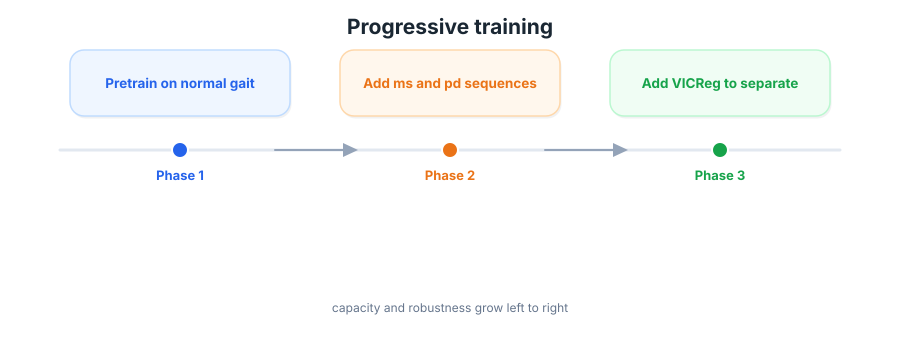

In [10]:
from IPython.display import SVG, display
display(SVG(filename=str(IMAGES_DIR / 'progressive_timeline.svg')))

## Use the locked, leakage-safe fold registry

The comparison is only meaningful on a split where clips from one source never straddle train and test. Notebook's Phase 0 froze such a split to `artifacts/eval/g1/fold_registry.json` (source-grouped, seed 42). We load fold 0 from it here rather than inventing a fresh split, so this notebook, notebook 05, and notebook 06 all sit on the identical partition.

> Source grouping is **provisional**: a `source_id` is a YouTube id, not a verified person, so everything here is a development estimate, never a clinical claim.


In [11]:
import json
from sjepa.data import load_index

records = load_index(KEYPOINTS_DIR)
by_clip = {r.clip_name: r for r in records}
registry = json.loads((ARTIFACT_DIR / 'eval' / 'g1' / 'fold_registry.json').read_text())
fold0 = registry['folds'][0]
train_recs = [by_clip[c] for c in fold0['train_clips']]
test_recs  = [by_clip[c] for c in fold0['test_clips']]
tr_src = {r.source_id for r in train_recs}; te_src = {r.source_id for r in test_recs}
assert not (tr_src & te_src), 'source leakage across the fold'
print('fold 0:', len(train_recs), 'train videos /', len(test_recs), 'test videos')
print('no source in both sides:', not (tr_src & te_src))

fold 0: 37 train videos / 10 test videos
no source in both sides: True


## Regime 1 - SSL continuation (no labels)

We rebuild the model, load the label-free checkpoint from notebook 03, and keep training with the exact same objective for a few hundred more updates. The label is never read. This asks: does more unlabeled training alone sharpen the representation?


In [12]:
from sjepa.config import get_config
from sjepa.models import build_model, pick_device
from sjepa.train_v2 import train_sjepa_v2, load_checkpoint_v2, save_checkpoint_v2
from sjepa.data import SequenceWindowDataset

cfg = get_config()
device = pick_device()
model = build_model(cfg, device=device, repaired=True)
load_checkpoint_v2(ARTIFACT_DIR / 'sjepa_ssl.pt', model, map_location=device)

ds_train = SequenceWindowDataset(train_recs, cfg.window_frames, cfg.window_stride)
SMOKE = cfg.profile.endswith('smoke')  # correct parse of SJEPA_SMOKE (not a raw truthiness test)
MORE = 40 if SMOKE else 400
state = train_sjepa_v2(model, ds_train, cfg, total_updates=MORE, device=device,
                       mask_ratio=0.6, log_every=max(1, MORE // 4))
save_checkpoint_v2(ARTIFACT_DIR / 'sjepa_ssl_continued.pt', model, cfg, train_state=state,
                   extra={'stage': 'ssl_continuation_fold0'})
print('continued SSL: final effective rank', round(state.eff_rank[-1], 1))

step     0 loss 7.7224 lr 2.50e-05 tau 0.99600 emb_std 0.4780 eff_rank 9.1
step   100 loss 1.2868 lr 9.33e-04 tau 0.99659 emb_std 0.5090 eff_rank 8.1
step   200 loss 1.1934 lr 5.87e-04 tau 0.99800 emb_std 0.6388 eff_rank 9.8
step   300 loss 0.8718 lr 1.79e-04 tau 0.99941 emb_std 0.6312 eff_rank 9.4
continued SSL: final effective rank 10.4


## A fixed, label-free read-out

To turn a video into one vector we mean-pool the frozen target encoder over a **fixed** pool of target tokens. The pool is chosen once from a seeded RNG and never from the test labels, so no information leaks from the evaluation into the representation. Both regimes below use this same read-out.


In [13]:
import numpy as np, torch
from sjepa.masking_v2 import sample_target_mask
from sjepa.data import sliding_windows

readout = sample_target_mask(cfg.num_joints, cfg.num_time_tokens,
                             np.random.default_rng(0), target_ratio=0.6)
tm = torch.from_numpy(readout).to(device)

def embed_records(m, recs):
    V, Y = [], []
    for r in recs:
        w = sliding_windows(r.load_norm(), cfg.window_frames, cfg.window_stride)
        x = torch.from_numpy(w).float().to(device)
        with torch.no_grad():
            V.append(m.embed(x, tm).mean(0).cpu().numpy())
        Y.append(r.label)
    return np.stack(V), Y

## Regime 2 - balanced supervised adaptation (labels only in the head)

Now we use the labels honestly: freeze the encoder and fit a class-balanced logistic head on the training embeddings, then score the held-out videos. The scaler and the head are fit on **training data only**. We do this on top of both the notebook-03 checkpoint and the SSL-continued one, so we can see whether extra unlabeled training moved the probe at all.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sjepa.eval import evaluate
LABELS = ['normal', 'ms', 'pd']

def probe_and_score(ckpt):
    m = build_model(cfg, device=device, repaired=True)
    load_checkpoint_v2(ckpt, m, map_location=device)
    Etr, ytr = embed_records(m, train_recs)
    Ete, yte = embed_records(m, test_recs)
    sc = StandardScaler().fit(Etr)               # fit on TRAIN only
    clf = LogisticRegression(max_iter=2000, class_weight='balanced')
    clf.fit(sc.transform(Etr), ytr)
    return evaluate(yte, clf.predict(sc.transform(Ete)), LABELS)

m_base = probe_and_score(ARTIFACT_DIR / 'sjepa_ssl.pt')
m_cont = probe_and_score(ARTIFACT_DIR / 'sjepa_ssl_continued.pt')
print(f'supervised probe on fold 0 held-out videos (macro-F1):')
print(f'  notebook-03 checkpoint : {m_base.macro_f1:.3f}')
print(f'  after SSL continuation : {m_cont.macro_f1:.3f}')

supervised probe on fold 0 held-out videos (macro-F1):
  notebook-03 checkpoint : 0.600
  after SSL continuation : 0.600


## Read this honestly

On this tiny fold the two numbers are close and noisy; do not over-read a few points either way. The point of the notebook is the **method**: labels live only in the supervised head, the SSL objective stays label-free, and the split is the locked, leakage-safe one. Notebook 06 runs this over all folds and puts it beside the Random Forest and the shortcut controls, which is where any real verdict lives. A single fold here proves nothing on its own.
